## Data Source

This project uses the Iris dataset obtained from GitHub:

- Original repository: https://gist.github.com/netj/8836201 
- Dataset file: iris.csv

All credit for the dataset belongs to the original author(s).

In [1]:
import torch
import torch.nn as nn 
import torch.nn.functional as F

In [2]:
## Create a model class that inherits nn.Module
class Model(nn.Module):
    # Input layer (4 features of the flower) --> Hidden layer H1 (number of neurons) --> Hidden layer H2 --> output (3 classes of iris flowers)
    def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
        super().__init__() #instantiate our nn.Module
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x)) #RELU - Rectified linear unit 
        x = F.relu(self.fc2(x))
        x = self.out(x)

        return x


In [3]:
# Pick a manual seed for randomization
torch.manual_seed(41)
# create an instance of model 
model = Model()


In [4]:
import pandas as pd
import matplotlib as plt 
%matplotlib inline

In [5]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv(url)

In [6]:
my_df.tail()

,sepal.length,sepal.width,petal.length,petal.width,variety
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica
149,5.9,3.0,5.1,1.8,Virginica


In [8]:
my_df['variety'] = my_df['variety'].replace('Setosa', 0.0).astype(float)
my_df['variety'] = my_df['variety'].replace('Versicolor', 1.0).astype(float)
my_df['variety'] = my_df['variety'].replace('Virginica', 2.0).astype(float)
my_df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [9]:
type('variety')

str

In [10]:
# Train test Split --> Set X & Y 
X = my_df.drop('variety', axis=1)
y = my_df['variety']

In [11]:
# Convert these to numpy arrays
X = X.values
y = y.values

In [12]:
from sklearn.model_selection import train_test_split
import numpy

In [13]:
# Train Test Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [14]:
# Convert X features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [15]:
# Convert y labels to tensors long 
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [16]:
# Set the criterion of the model to measure the error, how far off the predictions are from the data 
criterion = nn.CrossEntropyLoss()
# Choose Adam Optimizer, lr = Learning Rate (if error does not go down after a bunch of iterations (epochs), lower rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [17]:
# Train our model 
# Epochs (one run through all the training data in our network)
epochs = 100
losses = []
for i in range(epochs):
    # Go forward and get a prediction
    y_pred = model.forward(X_train) # Get predicted results

    # Measure the loss/error, gonna be high at first 
    loss = criterion(y_pred, y_train) # predicted values vs the y_train

    # Keep track of our losses
    losses.append(loss.item())

    # print every 10 epochs 
    if i % 10 == 0:
        print(f'Epoch: {i} and loss: {loss}')

    # Do some back propagation: take the error rate of forward propagation and feed it back through the network to fine tune the weights 
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


Epoch: 0 and loss: 1.125203251838684
Epoch: 10 and loss: 1.0097211599349976
Epoch: 20 and loss: 0.8162347078323364
Epoch: 30 and loss: 0.585993230342865
Epoch: 40 and loss: 0.4003389775753021
Epoch: 50 and loss: 0.26794716715812683
Epoch: 60 and loss: 0.1796349734067917
Epoch: 70 and loss: 0.12165624648332596
Epoch: 80 and loss: 0.0860651433467865
Epoch: 90 and loss: 0.06522615253925323


Text(0.5, 0, 'Epoch')

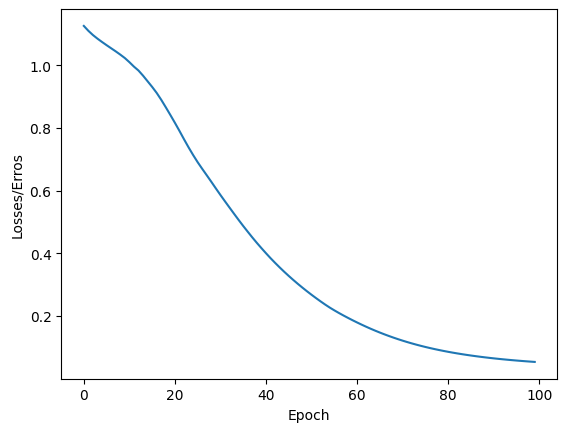

In [18]:
import matplotlib.pyplot as plt

#Graph it out! 

plt.plot(range(epochs), losses)
plt.ylabel("Losses/Erros")
plt.xlabel('Epoch')

In [19]:
# Evaluate the model on test data set (validate model on test set)
with torch.no_grad(): # Basically turn off back propogation 
    y_eval = model.forward(X_test) # X_test are features from our test set, y_eval will be predictions
    loss = criterion(y_eval, y_test) # Find the loss or error 

In [20]:
loss

tensor(0.1315)

In [21]:
correct = 0 
with torch.no_grad():
    for i, data in enumerate(X_test):
        y_val = model.forward(data)

        if y_test[i] == 0:
            x = "Setosa"
        elif y_test[1] == 1:
            x = "Versicolor"
        else:
            x = "Virginica"

        # will tell us what type of flower class our netowkr thinks it is
        print(f'{i+1}.) {str(y_val)} \t {x} \t {y_val.argmax().item()}')

        # correct or not 
        if y_val.argmax().item() == y_test[i]:
            correct += 1
print(f'We got {correct} correct!')

1.) tensor([-5.8771,  4.4629,  6.5155]) 	 Virginica 	 2
2.) tensor([-7.5451,  4.1668,  9.7293]) 	 Virginica 	 2
3.) tensor([-8.4517,  5.1275, 10.2015]) 	 Virginica 	 2
4.) tensor([-4.3411,  5.6280,  2.5636]) 	 Virginica 	 1
5.) tensor([-7.1838,  4.8757,  8.3023]) 	 Virginica 	 2
6.) tensor([-3.3940,  5.3421,  1.2802]) 	 Virginica 	 1
7.) tensor([-5.9240,  4.9826,  6.0025]) 	 Virginica 	 2
8.) tensor([-4.2895,  5.7016,  2.3920]) 	 Virginica 	 1
9.) tensor([-6.5369,  4.9261,  7.1291]) 	 Virginica 	 2
10.) tensor([-8.0526,  4.4129, 10.3325]) 	 Virginica 	 2
11.) tensor([-5.6775,  4.9505,  5.6248]) 	 Virginica 	 2
12.) tensor([ 4.5748, -2.2579, -2.8925]) 	 Setosa 	 0
13.) tensor([ 4.2646, -2.0055, -2.7342]) 	 Setosa 	 0
14.) tensor([-2.1081,  4.0482,  0.5803]) 	 Virginica 	 1
15.) tensor([ 3.4608, -1.2147, -2.3488]) 	 Setosa 	 0
16.) tensor([-5.4739,  5.1174,  5.0966]) 	 Virginica 	 1
17.) tensor([ 4.0637, -1.8045, -2.6504]) 	 Setosa 	 0
18.) tensor([-5.8090,  4.6057,  6.2494]) 	 Virginica

In [22]:
new_iris = torch.tensor([4.7, 3.2, 1.3, 0.2])

In [23]:
# Feed our new data back into our network 
with torch.no_grad():
    print(model(new_iris))

tensor([ 4.5445, -2.2478, -2.8698])


In [24]:
newer_iris = torch.tensor([5.9, 3.0, 5.1, 1.8])

In [25]:
# Feed our new data back into our network 
with torch.no_grad():
    print(model(newer_iris))

tensor([-5.9960,  4.5080,  6.6831])


In [28]:
# Save our NN Model 
torch.save(model.state_dict(),'iris_model.pt')

In [29]:
# Load the save Model 

new_model = Model()
new_model.load_state_dict(torch.load('iris_model.pt'))

<All keys matched successfully>

In [30]:
# Make sure it loaded correctly 
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)

In [31]:
newer_iris2 = torch.tensor([5.9, 3.0, 5.1, 1.8])

In [32]:
# testing the saved/loaded model
with torch.no_grad():
    print(new_model(newer_iris2))

tensor([-5.9960,  4.5080,  6.6831])
